In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

sales = pd.read_csv("qSales_2024.csv")

sales.head()

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.0,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.0,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.0,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.0,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.0,A


In [ ]:
sales = sales.loc[sales["tic"] == "TGT"].copy()

sales["datadate"] = pd.to_datetime(sales["datadate"])

sales = sales.sort_values("datadate").reset_index(drop=True)

sales["Time"] = range(1, len(sales) + 1)

display(sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,Time
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.0,A,1
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.0,A,2
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.0,A,3
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.0,A,4
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.0,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.0,A,89
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.0,A,90
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.0,A,91
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.0,A,92


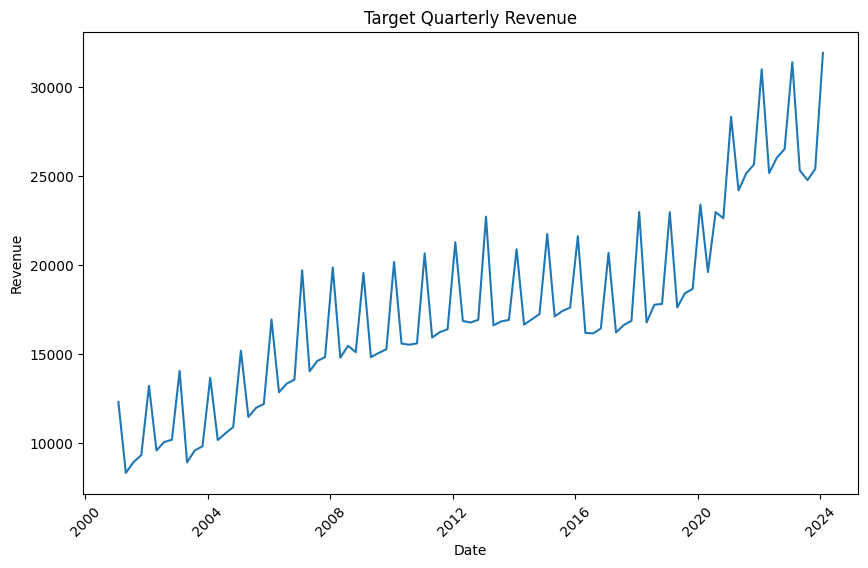

In [ ]:
plt.figure(figsize=(10,6))

plt.title("Target Quarterly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.plot(sales["datadate"], sales["saleq"])

plt.xticks(rotation=45)
plt.show()

In [ ]:
sales["Q1"] = np.where(sales["fqtr"] == 1, 1, 0)

sales["Q4"] = np.where(sales["fqtr"] == 4, 1, 0)

display(sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,Time,Q1,Q4
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.0,A,1,0,1
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.0,A,2,1,0
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.0,A,3,0,0
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.0,A,4,0,0
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.0,A,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.0,A,89,0,1
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.0,A,90,1,0
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.0,A,91,0,0
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.0,A,92,0,0


In [ ]:
y = sales.loc[:, "saleq"]

x = sales.loc[:, ["Time", "Q1", "Q4"]]

x = sm.add_constant(x)

model1 = sm.OLS(y, x).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  saleq   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     251.3
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           2.55e-43
Time:                        03:34:03   Log-Likelihood:                -824.72
No. Observations:                  93   AIC:                             1657.
Df Residuals:                      89   BIC:                             1668.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8490.5060    413.481     20.534      0.0

In [ ]:
model1_assessment = sales.copy()

model1_assessment["Predicted Revenue"] = model1.predict(x)

display(model1_assessment)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,Time,Q1,Q4,Predicted Revenue
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.0,A,1,0,1,13335.211466
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.0,A,2,1,0,8441.763866
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.0,A,3,0,0,8996.869879
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.0,A,4,0,0,9165.657854
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.0,A,5,0,1,14010.363368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.0,A,89,0,1,28188.553299
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.0,A,90,1,0,23295.105699
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.0,A,91,0,0,23850.211711
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.0,A,92,0,0,24018.999687


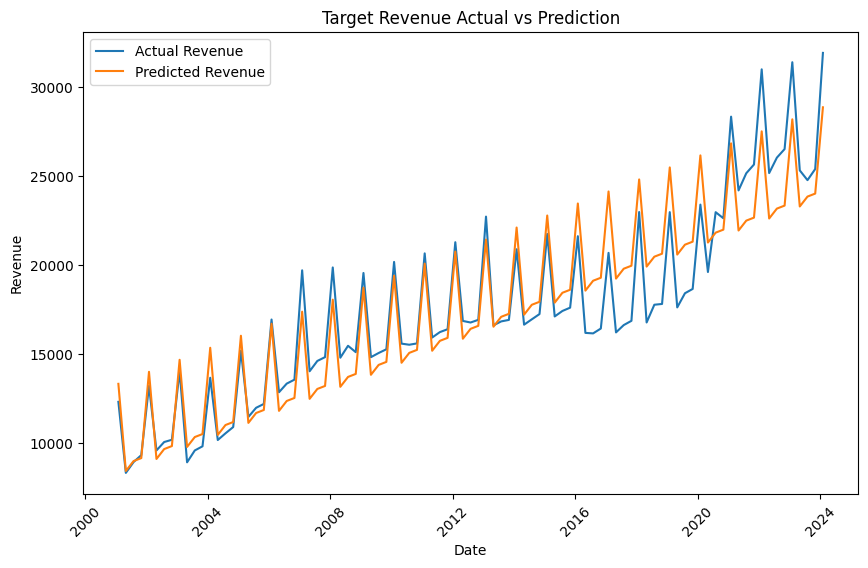

In [ ]:
plt.figure(figsize=(10,6))

plt.title("Target Revenue Actual vs Prediction")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.plot(
    model1_assessment["datadate"],
    model1_assessment["saleq"],
    label="Actual Revenue"
)

plt.plot(
    model1_assessment["datadate"],
    model1_assessment["Predicted Revenue"],
    label="Predicted Revenue"
)

plt.xticks(rotation=45)
plt.legend()
plt.show()

To: Chapman Wealth Management
From: QuantFolio Solutions
Re: Target Corporation Revenue Analysis

We analyzed Target Corporation’s quarterly revenue using a regression model with a time variable and two dummy variables for fiscal Q4 and Q1.

The Q4 dummy variable captures Target’s recurring holiday-season increase. The model estimates that Q4 revenue is approximately $4.4 billion higher than Q2 and Q3 revenue at the same point in time. The Q1 dummy variable captures the lower revenue that follows the holiday period. Q1 revenue is estimated to be approximately $232.8 million lower than Q2 and Q3 revenue, holding time constant.

The model explains approximately 89.5% of the variation in Target’s training revenue data. Its testing MAPE is 11.97%, meaning the predicted revenue differs from actual revenue by about 12% on average.

The results show long-term revenue growth and a consistent holiday-season peak. This is important for Chapman because Q4 performance should not be compared directly with a normal quarter without considering seasonality. However, actual revenue increased faster during the later testing period than the model predicted. Before investing, Chapman should also review Target’s profitability, inventory management, and margins to determine whether its recent revenue growth is sustainable.